In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir('..')

file_path = "data/raw/ibtracs_all_list_v04r01_vnm.csv"

df = pd.read_csv(file_path,
                 skiprows=[1],
                 low_memory=False,
                 na_values=[' ', ''])

# Clean thêm các giá trị string missing còn sót
missing_str = ['Missing', 'Not reported']
df = df.replace(missing_str, np.nan)

# Chuẩn hóa giá trị NATURE về tên ngắn (Mixture)
df['NATURE'] = df['NATURE'].str.split('(').str[0].str.strip()
print("NATURE sau chuẩn hóa:")
print(df['NATURE'].value_counts())

print(df.shape)

NATURE sau chuẩn hóa:
NATURE
Tropical         175333
Mixture           12443
Disturbance        9407
Extratropical      8050
Subtropical          12
Name: count, dtype: int64
(227142, 10)


1. Kiểm tra giá trị bất hợp lệ

In [2]:
print("=== KIỂM TRA GIÁ TRỊ BẤT HỢP LỆ ===")
print(f"LAT ngoài [-90, 90]     : {((df['LAT'] < -90) | (df['LAT'] > 90)).sum()}")
print(f"LON ngoài [0, 360]      : {((df['LON'] < 0) | (df['LON'] > 360)).sum()}")
print(f"WMO_WIND < 0            : {(df['WMO_WIND'] < 0).sum()}")
print(f"WMO_WIND > 200          : {(df['WMO_WIND'] > 200).sum()}")
print(f"WMO_PRES < 850          : {(df['WMO_PRES'] < 850).sum()}")
print(f"WMO_PRES > 1025         : {(df['WMO_PRES'] > 1025).sum()}")

=== KIỂM TRA GIÁ TRỊ BẤT HỢP LỆ ===
LAT ngoài [-90, 90]     : 0
LON ngoài [0, 360]      : 0
WMO_WIND < 0            : 0
WMO_WIND > 200          : 0
WMO_PRES < 850          : 0
WMO_PRES > 1025         : 0


Nhận xét: IBTrACS đã thực hiện quality control trước khi phân phối dataset => Ko cần xử lý thêm

2. Kiểm tra duplicate

In [3]:
# IBTrACS đôi khi có duplicate rows khi merge từ nhiều agency
# Cần kiểm tra trước khi interpolation — duplicate sẽ làm sai bước 6h time step

n_dup_full = df.duplicated().sum()
n_dup_key  = df.duplicated(subset=['SID', 'ISO_TIME']).sum()

print(f"Duplicate toàn bộ dòng           : {n_dup_full:,}")
print(f"Duplicate theo (SID, ISO_TIME)   : {n_dup_key:,}")

if n_dup_key > 0:
    print("\n→ Phát hiện duplicate theo khóa (SID, ISO_TIME). Tiến hành loại bỏ.")
    df = df.drop_duplicates(subset=['SID', 'ISO_TIME'], keep='first')
    print(f"   Sau khi loại bỏ: {df.shape[0]:,} dòng")
else:
    print("\n→ Không có duplicate theo (SID, ISO_TIME). Không cần xử lý thêm.")

Duplicate toàn bộ dòng           : 0
Duplicate theo (SID, ISO_TIME)   : 0

→ Không có duplicate theo (SID, ISO_TIME). Không cần xử lý thêm.


3. Convert

In [4]:
df['ISO_TIME'] = pd.to_datetime(df['ISO_TIME'], errors='coerce')

df['YEAR'] = df['ISO_TIME'].dt.year
df['MONTH'] = df['ISO_TIME'].dt.month
df['DECADE'] = (df['YEAR'] // 10) * 10

# Sort theo SID, ISO_TIME
df = df.sort_values(['SID', 'ISO_TIME']).reset_index(drop=True)

# Giữ SID có ít nhất 1 observation trong 2000–2025
YEAR_START, YEAR_END = 2000, 2025

valid_sids = df.loc[df['YEAR'].between(YEAR_START, YEAR_END), 'SID'].unique()
df = df[df['SID'].isin(valid_sids)].reset_index(drop=True)

# Kiểm tra edge case bão lấn ranh giới
cross_start = df[df['YEAR'] < 2000]['SID'].unique()
print(f"Số SID có điểm trước 2000 (track lấn từ 1999): {len(cross_start)}")
if len(cross_start) > 0:
    sid_ex = cross_start[0]
    print(df[df['SID'] == sid_ex][['SID', 'ISO_TIME', 'YEAR', 'LAT', 'LON']].head(6))

cross_end = df[df['YEAR'] > 2025]['SID'].unique()
print(f"\nSố SID có điểm sau 2025 (track lấn sang 2026): {len(cross_end)}")
if len(cross_end) > 0:
    sid_ex2 = cross_end[0]
    print(df[df['SID'] == sid_ex2][['SID', 'ISO_TIME', 'YEAR', 'LAT', 'LON']].tail(6))

print("\n=== KẾT QUẢ SAU CONVERT & LỌC ===")
print(f"Số SID giữ lại  : {len(valid_sids):,}")
print(f"Số dòng         : {df.shape[0]:,}")
print(f"Khoảng năm      : {int(df['YEAR'].min())} – {int(df['YEAR'].max())}")

print(df.head(5))

Số SID có điểm trước 2000 (track lấn từ 1999): 0

Số SID có điểm sau 2025 (track lấn sang 2026): 0

=== KẾT QUẢ SAU CONVERT & LỌC ===
Số SID giữ lại  : 719
Số dòng         : 40,847
Khoảng năm      : 2000 – 2025
             SID  NUMBER        BASIN       SUBBASIN            ISO_TIME  \
0  2000088N08090      21  North India  Bay of Bengal 2000-03-27 12:00:00   
1  2000088N08090      21  North India  Bay of Bengal 2000-03-27 15:00:00   
2  2000088N08090      21  North India  Bay of Bengal 2000-03-27 18:00:00   
3  2000088N08090      21  North India  Bay of Bengal 2000-03-27 21:00:00   
4  2000088N08090      21  North India  Bay of Bengal 2000-03-28 00:00:00   

     NATURE  LAT   LON  WMO_WIND  WMO_PRES  YEAR  MONTH  DECADE  
0  Tropical  7.5  90.0      25.0    1004.0  2000      3    2000  
1  Tropical  8.0  89.4       NaN       NaN  2000      3    2000  
2  Tropical  8.5  89.0      25.0    1006.0  2000      3    2000  
3  Tropical  9.0  89.0       NaN       NaN  2000      3    2000  
4 

Nhận xét:

Chiến lược lọc: Giữ mọi SID có ít nhất 1 observation trong [2000, 2025], sau đó giữ toàn bộ track của SID đó (kể cả điểm nằm ngoài ranh giới năm).

Kết quả kiểm tra edge case:
- Không có SID nào có điểm trước 2000 → Không có bão nào hình thành từ 1999 lấn sang 2000 trong phạm vi 2000km quanh Việt Nam.
- Không có SID nào có điểm sau 2025 → Không có bão nào trong 2025 kéo dài sang 2026 (hoặc IBTrACS chưa cập nhật track 2026 tại thời điểm thu thập).

=> Logic lọc hoạt động đúng. Dataset sau filter hoàn toàn nằm trong khoảng 2000–2025 với 719 cơn bão và 40,847 observation.

4. Phân tích Time Gap giữa các điểm trong track

=== THỐNG KÊ TIME GAP (giờ) ===
count    40128.00
mean         2.98
std          0.18
min          1.00
25%          3.00
50%          3.00
75%          3.00
max          3.00
Name: time_diff_h, dtype: float64

Giá trị gap phổ biến nhất (top 10):
time_diff_h
3.0    39743
1.0      299
2.0       86

=== PHÂN LOẠI TIME GAP ===
  ≤3h (chuẩn)                   :  40,128  (100.0%)
  3–6h (ngoại lệ)               :       0  (0.0%)
  6–12h (đứt đoạn)              :       0  (0.0%)
  >12h (nghiêm trọng)           :       0  (0.0%)

Storms có ít nhất 1 gap >6h  : 0
Storms có ít nhất 1 gap >12h : 0


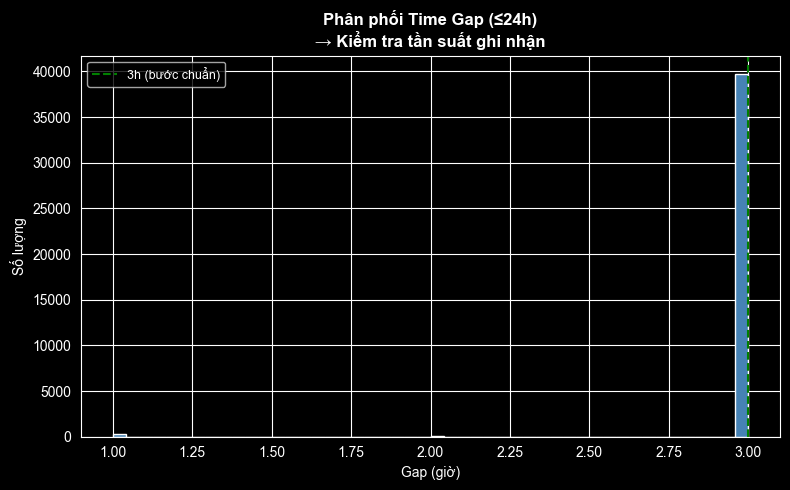

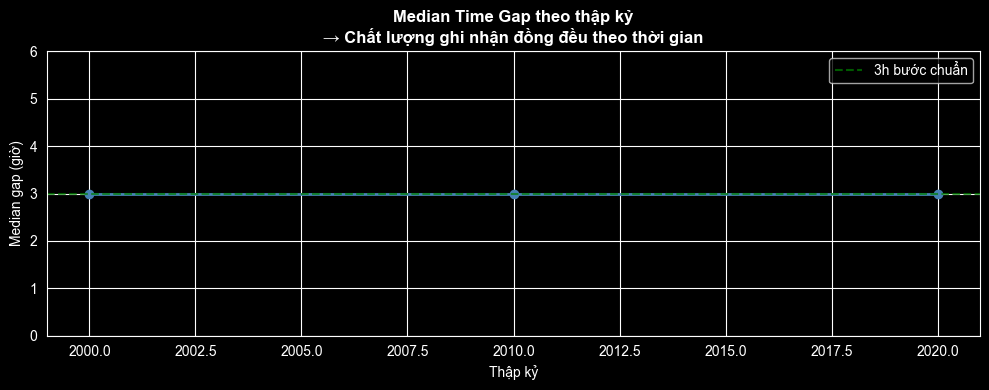

In [5]:
df['time_diff_h'] = (df.groupby('SID')['ISO_TIME'].diff().dt.total_seconds() / 3600)

gap_data = df['time_diff_h'].dropna()

print("=== THỐNG KÊ TIME GAP (giờ) ===")
print(gap_data.describe().round(2))
print(f"\nGiá trị gap phổ biến nhất (top 10):")
print(gap_data.value_counts().head(10).to_string())

# Phân loại mức độ gap
gap_bins   = [0, 3, 6, 12, float('inf')]
gap_labels = ['≤3h (chuẩn)', '3–6h (ngoại lệ)', '6–12h (đứt đoạn)', '>12h (nghiêm trọng)']
gap_cat    = pd.cut(gap_data, bins=gap_bins, labels=gap_labels, right=True)

print("\n=== PHÂN LOẠI TIME GAP ===")
gap_summary = gap_cat.value_counts().reindex(gap_labels)
for label, count in gap_summary.items():
    pct = count / len(gap_data) * 100
    print(f"  {label:30s}: {count:7,}  ({pct:.1f}%)")

storms_with_large_gap = df[df['time_diff_h'] > 6]['SID'].nunique()
storms_with_huge_gap  = df[df['time_diff_h'] > 12]['SID'].nunique()
print(f"\nStorms có ít nhất 1 gap >6h  : {storms_with_large_gap}")
print(f"Storms có ít nhất 1 gap >12h : {storms_with_huge_gap}")

# Histogram time gap
fig, ax = plt.subplots(figsize=(8, 5))
gap_data[gap_data <= 24].hist(bins=48, ax=ax, color='steelblue', edgecolor='white')
ax.axvline(x=3, color='green', linestyle='--', linewidth=1.5, label='3h (bước chuẩn)')
ax.set_title('Phân phối Time Gap (≤24h)\n→ Kiểm tra tần suất ghi nhận', fontweight='bold')
ax.set_xlabel('Gap (giờ)')
ax.set_ylabel('Số lượng')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Median gap theo DECADE
gap_decade_median = (df.dropna(subset=['DECADE', 'time_diff_h'])
                       .groupby('DECADE')['time_diff_h'].median())

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(gap_decade_median.index, gap_decade_median.values,
        marker='o', color='steelblue', linewidth=2)
ax.axhline(y=3, color='green', linestyle='--', alpha=0.7, label='3h bước chuẩn')
ax.set_ylim(0, 6)
ax.set_xlabel('Thập kỷ')
ax.set_ylabel('Median gap (giờ)')
ax.set_title('Median Time Gap theo thập kỷ\n→ Chất lượng ghi nhận đồng đều theo thời gian',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

df = df.drop(columns=['time_diff_h'], errors='ignore')

Nhận xét:
- Toàn bộ 40,128 gap đều ≤3h (100%) - không có track đứt đoạn trong dataset
2000–2025.
- Gap 3h chiếm 99.0% (39,743 records), gap 1h (299) và 2h (86) là các supplemental fixes do IBTrACS chèn thêm tại thời điểm đặc biệt (đổ bộ, cực đại cường độ) - không phải bất thường.
- Median gap ổn định tại 3h xuyên suốt ba thập kỷ, xác nhận chất lượng ghi nhận đồng đều, không suy giảm theo thời gian.

→ Không có track đứt đoạn → tính liên tục thời gian được đảm bảo, tiered interpolation ở bước sau có cơ sở áp dụng.

5. Tổng kết

In [6]:
print("TỔNG KẾT INITIAL CLEANING")
print(f"Số dòng                 : {df.shape[0]:,}")
print(f"Số cột                  : {df.shape[1]}")
print(f"Khoảng năm              : {int(df['YEAR'].min())} – {int(df['YEAR'].max())}")
print(f"Số storm duy nhất       : {df['SID'].nunique():,}")
print("Duplicate               : không có")
print("Time step               : không có")
print("Range check             : không phát hiện giá trị bất hợp lý nghiêm trọng")
print()

TỔNG KẾT INITIAL CLEANING
Số dòng                 : 40,847
Số cột                  : 13
Khoảng năm              : 2000 – 2025
Số storm duy nhất       : 719
Duplicate               : không có
Time step               : không có
Range check             : không phát hiện giá trị bất hợp lý nghiêm trọng



In [7]:
df.to_csv("data/processed/01_initial_cleaned.csv", index=False)